# Personal Loan Prediction

This notebook explores a bank customer dataset and compares multiple machine-learning models for predicting personal-loan acceptance.

> **Data note:** the raw dataset is not included in this public repository. Place the CSV at `../data/Bank_Personal_Loan_Modelling.csv` before running the notebook.

The workflow includes data cleaning, exploratory analysis, ZIP-code geocoding, Logistic Regression, Gaussian Naive Bayes, K-Nearest Neighbors, cross-validation, and model comparison.


In [271]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics
import pgeocode
from IPython.display import IFrame
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier

In [272]:
file_path = '../data/Bank_Personal_Loan_Modelling.csv'
data = pd.read_csv(file_path)

In [273]:
data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


the correlation between age and experience: 
                 Age  Experience
Age         1.000000    0.994215
Experience  0.994215    1.000000


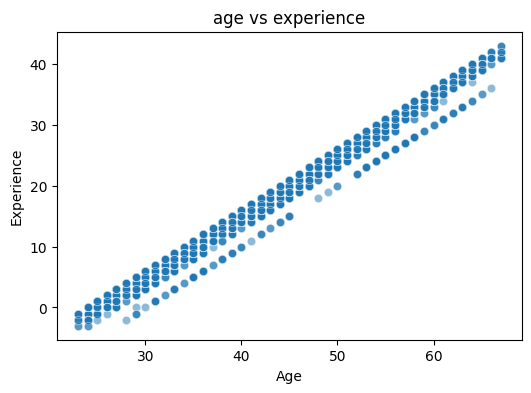

In [274]:
corr = data[["Age", "Experience"]].corr()
print("the correlation between age and experience: ")
print(corr)

plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Experience", data=data, alpha=0.5)
plt.title("age vs experience")
plt.show()

The relationship between Age and Experience is checked and visualized.
As we can see strong correlation was found meaning one of them can be safely removed.

In [275]:
data = data.drop(columns=["ID", "Experience"])

In [276]:
data

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,49,91107,4,1/60,1,0,0,1,0,0,0
1,45,34,90089,3,1/50,1,0,0,1,0,0,0
2,39,11,94720,1,1/00,1,0,0,0,0,0,0
3,35,100,94112,1,2/70,2,0,0,0,0,0,0
4,35,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,40,92697,1,1/90,3,0,0,0,0,1,0
4996,30,15,92037,4,0/40,1,85,0,0,0,1,0
4997,63,24,93023,2,0/30,3,0,0,0,0,0,0
4998,65,49,90034,3,0/50,2,0,0,0,0,1,0


In [277]:
data['CCAvg'] = data['CCAvg'].apply(lambda x: float(x.replace('/', '.')))

Values on CCAvg re clened and converted to numeric format

In [278]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Income              5000 non-null   int64  
 2   ZIP Code            5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal Loan       5000 non-null   int64  
 8   Securities Account  5000 non-null   int64  
 9   CD Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


In [279]:
for col in data:
    print(f"{col}: {data[col].unique()}\n")

Age: [25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]

Income: [ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120  99 111  33 129 122 150 195 110 101 191 140 153 173 174
  90 179 145 200 183 182  88 160 205 164  14 175 103 108 185 204 154 102
 192 202 162 142  95 184 181 143 123 178 198 201 203 189 151 199 224 218]

ZIP Code: [91107 90089 94720 94112 91330 92121 91711 93943 93023 94710 90277 93106
 94920 91741 95054 95010 94305 91604 94015 90095 91320 95521 95064 90064
 94539 94104 94117 94801 94035 92

In [280]:
data.describe(include="all")

,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [281]:
data["CCAvg"] = data["CCAvg"]*12

CCAvg is multiplied by 12 to convert it to yearly

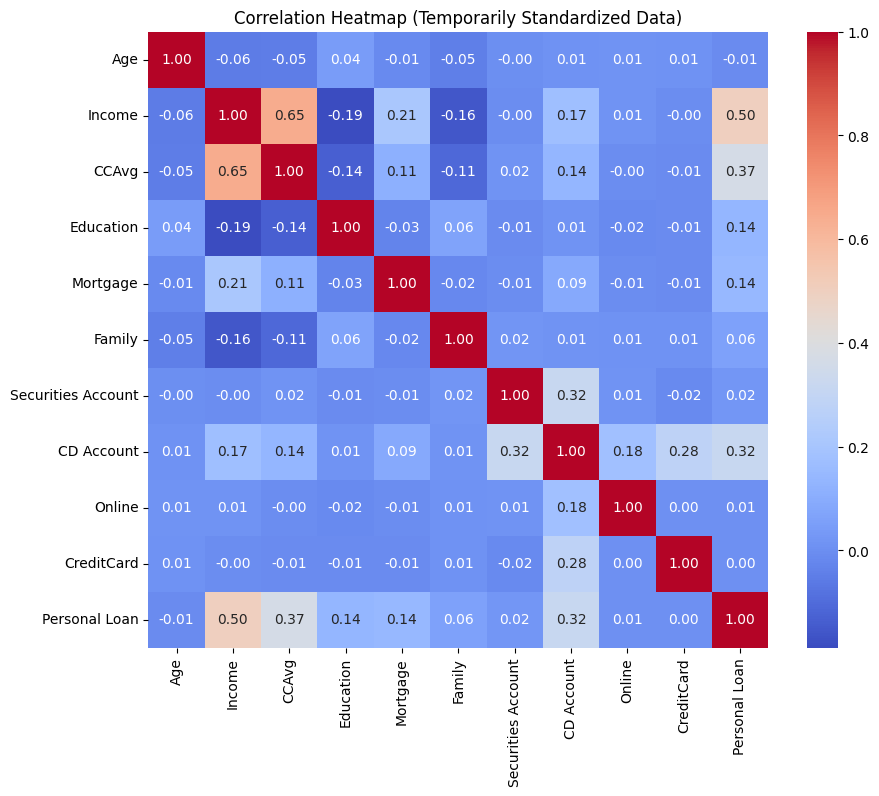

In [282]:
num_cols = ['Age', 'Income', 'CCAvg', 'Education', 'Mortgage',
             'Family', 'Securities Account', 'CD Account', 'Online', 'CreditCard', 'Personal Loan']

temp = data[num_cols].copy()

scaler = StandardScaler()
temp_scaled = pd.DataFrame(scaler.fit_transform(temp), columns=num_cols)

plt.figure(figsize=(10,8))
sns.heatmap(temp_scaled.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Temporarily Standardized Data)")
plt.show()

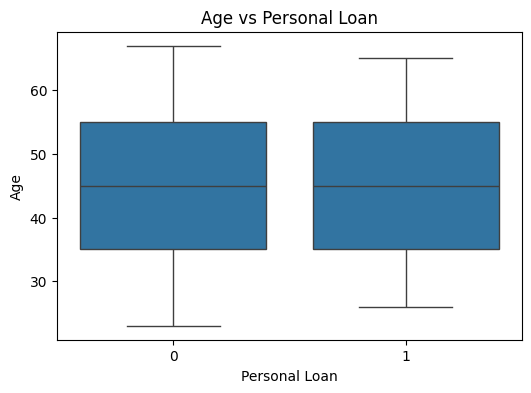

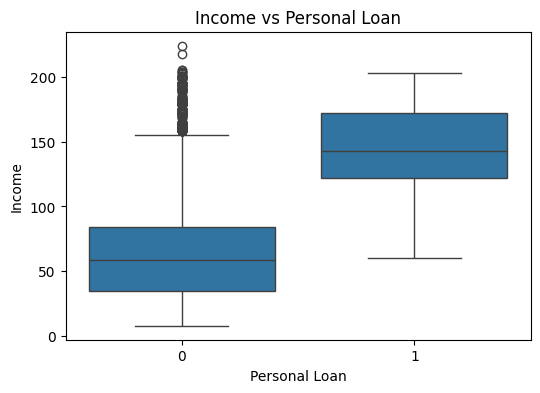

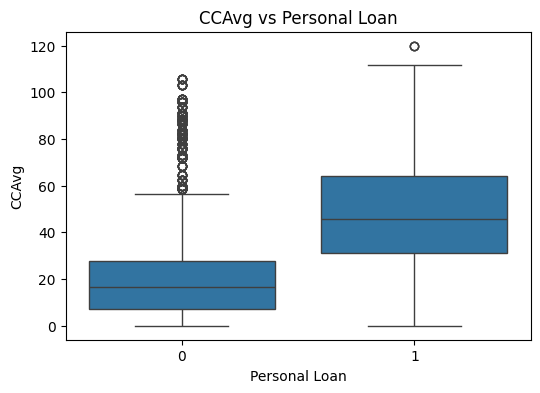

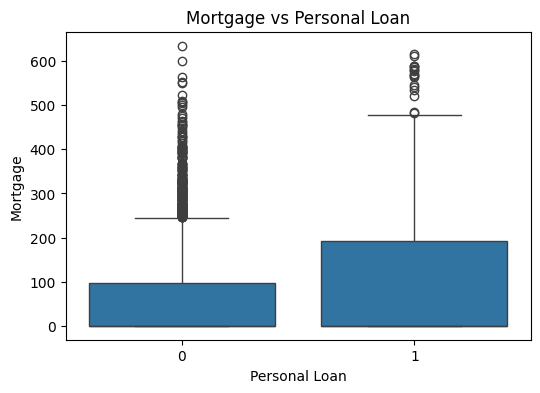

In [283]:
numerical = ['Age', 'Income', 'CCAvg', 'Mortgage']

for col in numerical:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Personal Loan', y=col, data=data)
    plt.title(f'{col} vs Personal Loan')
    plt.show()

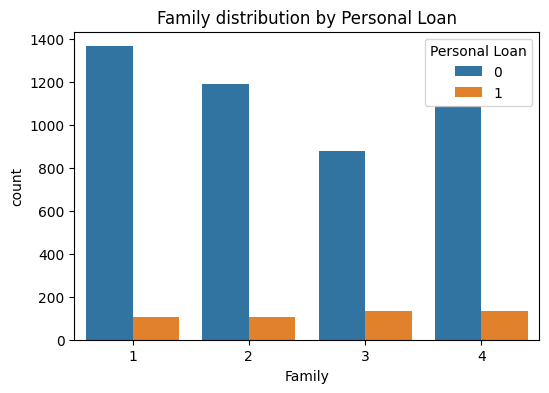

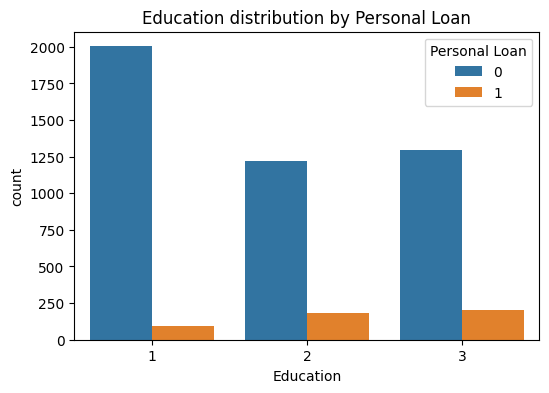

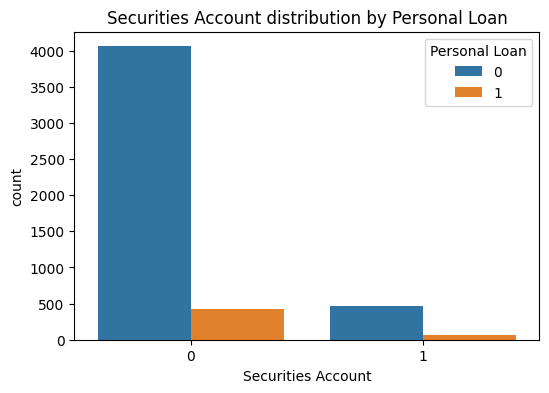

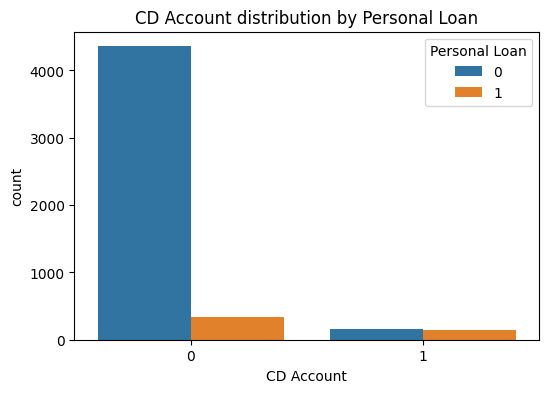

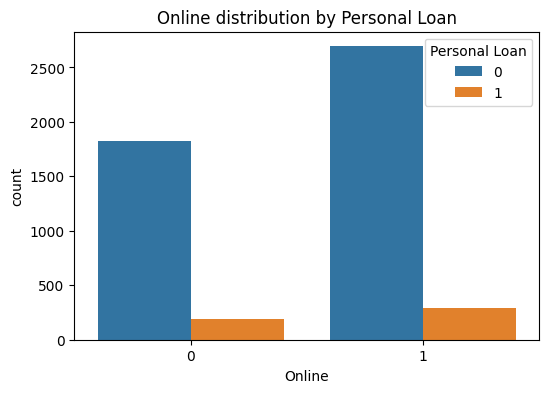

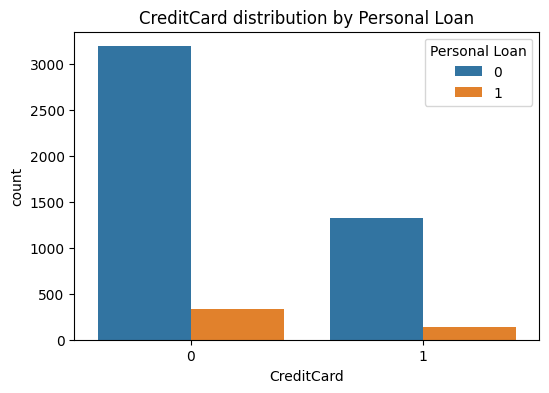

In [284]:
categorical = ['Family', 'Education', 'Securities Account', 
               'CD Account', 'Online', 'CreditCard']


for col in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Personal Loan', data=data)
    plt.title(f'{col} distribution by Personal Loan')
    plt.show()

In [285]:
print(data['ZIP Code'].nunique(), "unique ZIP codes out of", len(data))
print(data['ZIP Code'].value_counts().head(10))

467 unique ZIP codes out of 5000
ZIP Code
94720    169
94305    127
95616    116
90095     71
93106     57
93943     54
92037     54
91320     53
91711     52
94025     52
Name: count, dtype: int64


ZIP code distribution is inspected to prepare for geographical visualization

In [286]:
data['ZIP Code'] = (data['ZIP Code'].astype(str)
                                   .str.replace(r'\D','', regex=True)
                                   .str.zfill(5))

nomi = pgeocode.Nominatim('us')
zip_unique = pd.Series(data['ZIP Code'].unique(), name='ZIP Code')
zip_geo = nomi.query_postal_code(zip_unique.tolist())

if 'postal_code' in zip_geo.columns:
    zip_geo = zip_geo.rename(columns={'postal_code':'ZIP Code'})

zip_geo = zip_geo[['ZIP Code','latitude','longitude']].copy()

print("zip_geo head:\n", zip_geo.head())
print("zip_geo NaNs:", zip_geo['latitude'].isna().sum(), zip_geo['longitude'].isna().sum())

data = data.merge(zip_geo, on='ZIP Code', how='left')

data = data.rename(columns={'latitude':'Latitude', 'longitude':'Longitude'})

print(data[['ZIP Code','Latitude','Longitude']].head())
print("NaN coords after merge:", data['Latitude'].isna().sum(), data['Longitude'].isna().sum())

zip_geo head:
   ZIP Code  latitude  longitude
0    91107   34.1510  -118.0889
1    90089   33.7866  -118.2987
2    94720   37.8738  -122.2549
3    94112   37.7195  -122.4411
4    91330   34.2283  -118.5368
zip_geo NaNs: 5 5
  ZIP Code  Latitude  Longitude
0    91107   34.1510  -118.0889
1    90089   33.7866  -118.2987
2    94720   37.8738  -122.2549
3    94112   37.7195  -122.4411
4    91330   34.2283  -118.5368
NaN coords after merge: 41 41


ZIP codes are converted into latitude and longitude using pgeocode
The coordinates are merged back into the main dataset for map plotting

In [287]:
data['ZIP Code'] = (data['ZIP Code'].astype(str)
                                   .str.replace(r'\D','', regex=True)
                                   .str.zfill(5))

nomi = pgeocode.Nominatim('us')
zip_df = pd.DataFrame({'ZIP Code': data['ZIP Code'].unique()})
geo = nomi.query_postal_code(zip_df['ZIP Code'].tolist())
if 'postal_code' in geo.columns:
    geo = geo.rename(columns={'postal_code':'ZIP Code'})
geo = geo[['ZIP Code','latitude','longitude']].rename(
    columns={'latitude':'Latitude','longitude':'Longitude'}
)

data = data.drop(columns=[c for c in data.columns
                          if c.lower() in ('latitude','longitude')], errors='ignore')
data = data.merge(geo, on='ZIP Code', how='left')

df_geo = data.dropna(subset=['Latitude','Longitude']).copy()
zip_summary = (df_geo.groupby(['ZIP Code','Latitude','Longitude'], as_index=False)['Personal Loan']
                     .mean().rename(columns={'Personal Loan':'Loan_Rate'}))

fig = px.scatter_geo(
    zip_summary,
    lat='Latitude', lon='Longitude',
    color='Loan_Rate', size='Loan_Rate', size_max=18,
    projection='albers usa', scope='usa',
    title='Personal Loan Acceptance Rate by ZIP Code'
)
fig.update_traces(marker_line_width=0)
fig.write_html("loan_geo_plot.html")
IFrame("loan_geo_plot.html", width=900, height=600)

An interactive map is shown to visualize where most customers are located

In [288]:
X = data.drop(columns=['Personal Loan', 'ZIP Code', 'Latitude', 'Longitude'], errors='ignore')
y = data['Personal Loan']

In [289]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [290]:
logreg = LogisticRegression(solver="liblinear")
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [291]:
print("Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.9526666666666667


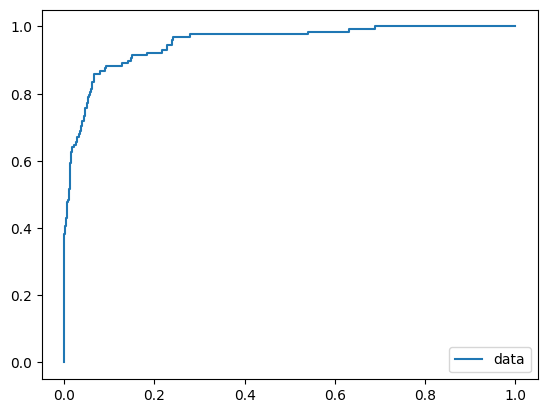

In [292]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label="data")
plt.legend(loc=4)
plt.show()

The ROC curve is plotted to visualize the trade off between true-positive and false-positive rates

In [293]:
logreg.intercept_

array([-9.34492771])

In [294]:
logreg.coef_

array([[-1.64890393e-02,  4.18015995e-02,  4.03182372e-01,
         1.09585328e-02,  1.30081246e+00,  7.14718749e-04,
        -6.39455722e-01,  3.18734647e+00, -7.79744222e-01,
        -9.49169225e-01]])

In [295]:
logreg.predict_proba(X)

array([[9.94645160e-01, 5.35483980e-03],
       [9.98638115e-01, 1.36188506e-03],
       [9.99544056e-01, 4.55943585e-04],
       ...,
       [9.90360941e-01, 9.63905918e-03],
       [9.94889111e-01, 5.11088922e-03],
       [9.95723948e-01, 4.27605155e-03]])

In [296]:
logreg.predict(X)

array([0, 0, 0, ..., 0, 0, 0])

In [297]:
logreg.score(X, y)

0.9492

In [298]:
confusion_matrix(y_test, y_pred)

array([[1355,   17],
       [  54,   74]])

In [299]:
confusion_matrix(y, logreg.predict(X))

array([[4460,   60],
       [ 194,  286]])

A confusion matrix is built to show correct and incorrect predictions on the test set

In [300]:
print(classification_report(y, logreg.predict(X)))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      4520
           1       0.83      0.60      0.69       480

    accuracy                           0.95      5000
   macro avg       0.89      0.79      0.83      5000
weighted avg       0.95      0.95      0.95      5000



In [301]:
solvers = ['liblinear', 'lbfgs', 'saga']
for s in solvers:
    model = LogisticRegression(solver=s, C=0.5, max_iter=5000)
    model.fit(X_train, y_train)
    print(f"{s} Accuracy:", model.score(X_test, y_test))

liblinear Accuracy: 0.9473333333333334
lbfgs Accuracy: 0.9546666666666667
saga Accuracy: 0.9233333333333333


Different optimization solvers for Logistic Regression are tested
Their accuracy scores are compared to choose the most stable solver

In [302]:
X = data.drop(columns=['Personal Loan', 'ZIP Code', 'Latitude', 'Longitude'], errors='ignore')
y = data['Personal Loan']

X_scaled = scaler.fit_transform(X)
k = 5  
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

result = cross_val_score(logreg, X_scaled, y, cv=kfold)

print(result)
print(np.mean(result))

[0.954 0.947 0.948 0.947 0.96 ]
0.9512


In [303]:
clf = GaussianNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

The Gaussian Naive Bayes algorithm was chosen because all the features in the dataset are numerical and approximately continuous but as we can say Naive Bayes is not our best option for this dataset

In [304]:
print("Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.886


In [305]:
confusion_matrix(y_test, y_pred)

array([[1254,  118],
       [  53,   75]])

In [306]:
confusion_matrix(y, clf.predict(X))

array([[4141,  379],
       [ 201,  279]])

In [307]:
print(classification_report(y, clf.predict(X)))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      4520
           1       0.42      0.58      0.49       480

    accuracy                           0.88      5000
   macro avg       0.69      0.75      0.71      5000
weighted avg       0.90      0.88      0.89      5000



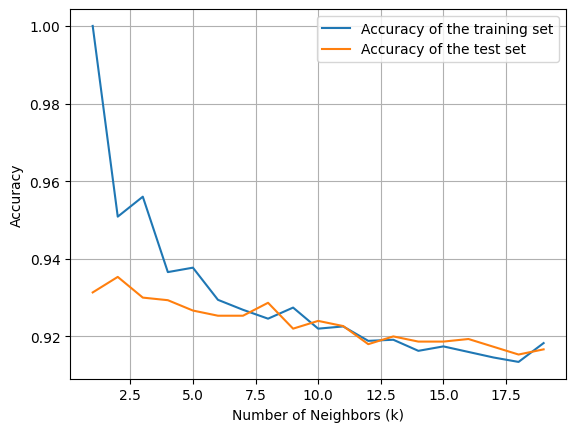

In [308]:
training_acc = []  
test_acc = []       

neighbors_settings = range(1, 20)   

for neighbors in neighbors_settings:
    knn = KNeighborsClassifier(n_neighbors=neighbors)
    knn.fit(X_train, y_train)                 
    training_acc.append(knn.score(X_train, y_train))  
    test_acc.append(knn.score(X_test, y_test))       


plt.plot(neighbors_settings, training_acc, label='Accuracy of the training set')
plt.plot(neighbors_settings, test_acc, label='Accuracy of the test set')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.legend()
plt.grid(True)
plt.show()

In [309]:
print(np.max(training_acc))
print(np.max(test_acc))

1.0
0.9353333333333333


In [310]:
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

k_list = range(3, 20, 2)
scores = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train_s, y_train, cv=5)
    scores.append(cv_scores.mean())

best_k = k_list[np.argmax(scores)]
print("Best k:", best_k)
print("Mean CV Accuracy:", max(scores))

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_s, y_train)
print("Test Accuracy:", knn_final.score(X_test_s, y_test))

Best k: 3
Mean CV Accuracy: 0.9582857142857144
Test Accuracy: 0.9673333333333334


In these cells the KNN algorithm was tested with different values of k to find the optimal number of neighbors
A loop and a plot of training vs. testing accuracy were used to observe how the model’s performance changed as k increased
After trying several values using k = 3 clusters gave better accuracy than higher values such as 9

In [311]:
knn= KNeighborsClassifier(3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.93


In [312]:
confusion_matrix(y_test, y_pred)

array([[1334,   38],
       [  67,   61]])

In [313]:
confusion_matrix(y, knn.predict(X))

array([[4437,   83],
       [ 176,  304]])

In [314]:
print(classification_report(y, knn.predict(X)))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4520
           1       0.79      0.63      0.70       480

    accuracy                           0.95      5000
   macro avg       0.87      0.81      0.84      5000
weighted avg       0.94      0.95      0.95      5000



In [315]:
from sklearn.metrics import log_loss, accuracy_score

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logreg    = LogisticRegression(max_iter=2000).fit(X_train_s, y_train)
clf        = GaussianNB().fit(X_train_s, y_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(X_train_s, y_train)   

proba_lr   = logreg.predict_proba(X_test_s)[:, 1]
proba_clf   = clf.predict_proba(X_test_s)[:, 1]
proba_knn  = knn.predict_proba(X_test_s)[:, 1]

cost_lr  = log_loss(y_test, proba_lr)
cost_clf  = log_loss(y_test, proba_clf)
cost_knn = log_loss(y_test, proba_knn)

y_pred_knn = knn.predict(X_test_s)

print("LogReg:", round(cost_lr, 4))
print("GNB:", round(cost_clf, 4))
print("KNN:", round(cost_knn, 4))

LogReg: 0.1246
GNB: 0.4771
KNN: 0.4736


The cost functions of all three models were calculated to compare their performance more fairly
For Logistic Regression, Naive Bayes and KNN the Log-Loss was used to measure how accurate the probability predictions were
After checking the results Logistic Regression showed the lowest loss value which means it made the most reliable predictions among the three models

In [316]:
new_data = pd.DataFrame([{
    'Age': 42,
    'Income': 30,
    'ZIP Code': 92037,
    'Family': 3,
    'CCAvg': 1.2 * 12,
    'Education': 3,
    'Mortgage': 0,
    'Securities Account': 1,
    'CD Account': 0,
    'Online': 1,
    'CreditCard': 1,
    'Latitude': 32.85,
    'Longitude': -117.25
}])
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

X_scaled = scaler.transform(new_data.values)

print("LogReg:",     logreg.predict(X_scaled)[0])
print("NaiveBayes:", clf.predict(X_scaled)[0])
print("KNN:",        knn_final.predict(X_scaled)[0])

LogReg: 0
NaiveBayes: 0
KNN: 0


And finally we have the final predictions with three algorithms